In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("../cleanData.csv")

###  One-Hot Encoding for Month

In [3]:
month_dummies = pd.get_dummies(df['Month'], prefix='Month', drop_first=False)
df = pd.concat([df, month_dummies], axis=1)
df = df.drop(columns=['Month', 'Date', 'Year'])
df.drop(columns=['Month_sin', 'Month_cos'], inplace=True)

In [4]:
month_feature = df[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

In [20]:
df.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'], inplace=True)

In [22]:
month_feature.sample(4)

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
646,False,False,False,False,False,False,False,False,True,False,False,False
3341,False,False,False,False,False,False,False,True,False,False,False,False
3185,False,False,False,True,False,False,False,False,False,False,False,False
3887,False,False,True,False,False,False,False,False,False,False,False,False


In [59]:
df.columns

Index(['Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'Average_Bleaching',
       'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
       'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'SSTA_Rolling_Mean', 'TSA_Rolling_Mean',
       'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'],
      dtype='object')

# PCA

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
X = df.drop("Average_Bleaching", axis=1)
Y = df["Average_Bleaching"]

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [26]:

df.columns

Index(['Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'Average_Bleaching',
       'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
       'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'SSTA_Rolling_Mean', 'TSA_Rolling_Mean'],
      dtype='object')

In [6]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [11]:
X_test_ss

(1223, 49)

In [7]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

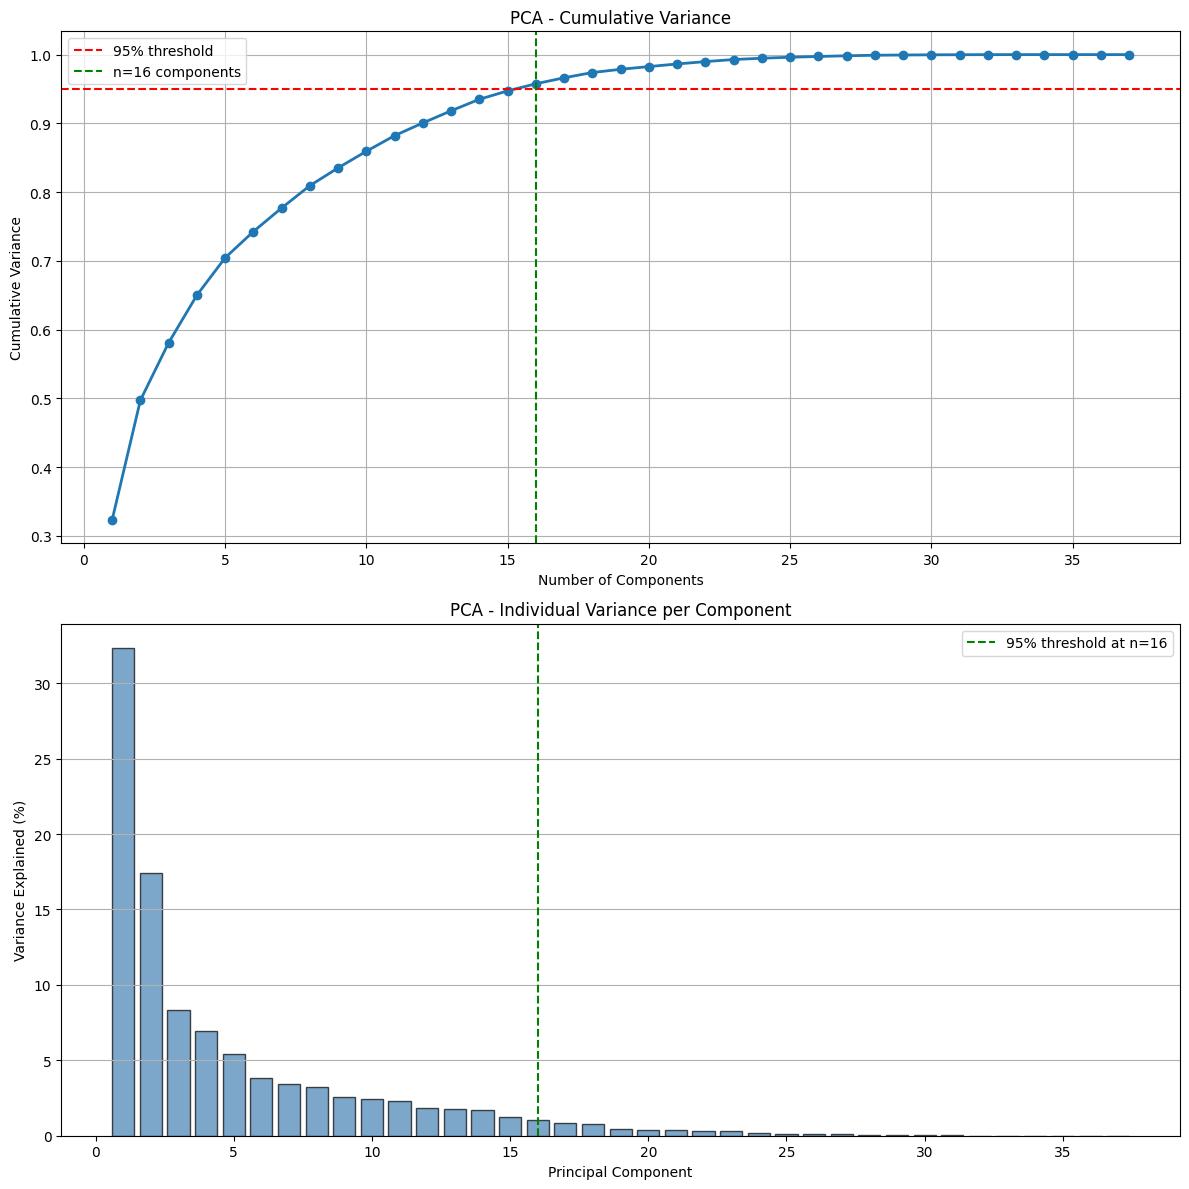

✅ Components needed for 95% variance: 16
✅ Variance explained by 16 components: 0.9576


In [55]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'n={n_components_95} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'95% threshold at n={n_components_95}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Variance explained by {n_components_95} components: {cumvar[n_components_95-1]:.4f}")

In [53]:
print(pca.explained_variance_)

[1.19601383e+01 6.44283779e+00 3.09469259e+00 2.56001087e+00
 2.01280713e+00 1.41249094e+00 1.26872146e+00 1.20272805e+00
 9.57425249e-01 8.94423311e-01 8.41538533e-01 6.82855349e-01
 6.53090615e-01 6.21011430e-01 4.49778077e-01 3.85163977e-01
 3.20449471e-01 2.82956982e-01 1.73851533e-01 1.46595598e-01
 1.40698033e-01 1.26778712e-01 1.11825574e-01 7.05172596e-02
 5.28457740e-02 4.05151614e-02 3.79377943e-02 2.93135545e-02
 1.29069462e-02 9.48154690e-03 5.94400415e-03 3.33539827e-03
 2.40094527e-03 3.14880509e-06 1.24402398e-06 9.17217198e-07
 3.93187811e-08]


# lazyPredict

In [21]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [13]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

                               Adjusted R-Squared     R-Squared        RMSE  \
Model                                                                         
ExtraTreesRegressor                      0.364404      0.374810    6.606928   
HistGradientBoostingRegressor            0.323797      0.334868    6.814713   
XGBRegressor                             0.304601      0.315986    6.910766   
MLPRegressor                             0.280919      0.292692    7.027452   
KNeighborsRegressor                      0.254295      0.266503    7.156369   
RandomForestRegressor                    0.218651      0.231443    7.325405   
GradientBoostingRegressor                0.158716      0.172489    7.601170   
PoissonRegressor                         0.138638      0.152740    7.691338   
BaggingRegressor                         0.089529      0.104435    7.907554   
BayesianRidge                            0.056766      0.072208    8.048573   
RidgeCV                                  0.054542   

# OpTuna

In [36]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor

In [ ]:
def rf_objective(trial):

    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1,
        random_state=42
    )

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        # ('selector', SelectKBest(score_func=f_regression,
        #                          k=trial.suggest_int("k_features", 5, X.shape[1]))),
        ('pca', PCA(
            n_components= 0.95 #trial.suggest_float("pca_variance", 0.90, 0.99)
        )),
        ('model', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train_raw,
        y_train,
        cv=4,
        scoring='r2',
        n_jobs=-1
    )

    return scores.mean()

rf_study = optuna.create_study(direction="maximize")

rf_study.optimize(rf_objective, n_trials=50)

print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

In [23]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter=trial.suggest_int("max_iter", 50, 400),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.1),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 0.0, 1.0),
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X_train_raw, y_train, cv=4, scoring='r2', n_jobs=-1)
    return scores.mean()

hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)
print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")


[I 2026-05-04 20:08:37,975] A new study created in memory with name: no-name-7a6036ae-8041-45f9-b0d0-a19c414b7bb3
[I 2026-05-04 20:08:39,764] Trial 0 finished with value: 0.21890046186954215 and parameters: {'max_iter': 358, 'max_depth': 4, 'learning_rate': 0.02842865319954193, 'min_samples_leaf': 17, 'l2_regularization': 0.8546072849262135}. Best is trial 0 with value: 0.21890046186954215.
[I 2026-05-04 20:08:41,814] Trial 1 finished with value: 0.2698027312896647 and parameters: {'max_iter': 321, 'max_depth': 15, 'learning_rate': 0.030836673243815695, 'min_samples_leaf': 22, 'l2_regularization': 0.9441217831328031}. Best is trial 1 with value: 0.2698027312896647.
[I 2026-05-04 20:08:43,291] Trial 2 finished with value: 0.25943590077049306 and parameters: {'max_iter': 94, 'max_depth': 8, 'learning_rate': 0.05145810706631204, 'min_samples_leaf': 2, 'l2_regularization': 0.34677952862787886}. Best is trial 1 with value: 0.2698027312896647.
[I 2026-05-04 20:08:44,294] Trial 3 finished wit

========== HGB BEST ==========
{'max_iter': 184, 'max_depth': 14, 'learning_rate': 0.04279841354500047, 'min_samples_leaf': 7, 'l2_regularization': 0.5279486576376311}
Best R²: 0.2909


In [24]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 400),
        max_depth=trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1,
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X_train_raw, y_train, cv=4, scoring='r2', n_jobs=-1)
    return scores.mean()

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")


[I 2026-05-04 20:09:14,288] A new study created in memory with name: no-name-bd8d6eba-908a-4a95-a139-78cffc3f1990
[I 2026-05-04 20:09:15,095] Trial 0 finished with value: 0.22452744661858662 and parameters: {'n_estimators': 357, 'max_depth': 39, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.22452744661858662.
[I 2026-05-04 20:09:16,090] Trial 1 finished with value: 0.3107729550220634 and parameters: {'n_estimators': 344, 'max_depth': 25, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.3107729550220634.
[I 2026-05-04 20:09:16,863] Trial 2 finished with value: 0.25540172772187375 and parameters: {'n_estimators': 323, 'max_depth': 19, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.3107729550220634.
[I 2026-05-04 20:09:17,683] Trial 3 finished with value: 0.20393528543099043 and parameters: {'n_estimators': 370, 'max_depth': 34, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with v

========== ET BEST ==========
{'n_estimators': 380, 'max_depth': 24, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best R²: 0.3148


In [25]:
def xgb_objective(trial):

    model = xgb.XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 400),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.1),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        n_jobs=-1,
        random_state=42
    )

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        # ('selector', SelectKBest(
        #     score_func=f_regression,
        #     k=trial.suggest_int("k_features", 5, X.shape[1])
        # )),
        ('pca', PCA(
            n_components= 0.95 #trial.suggest_float("pca_variance", 0.90, 0.99)
        )),
        ('model', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train_raw,
        y_train,
        cv=4,
        scoring='r2',
        n_jobs=-1
    )

    return scores.mean()

xgb_study = optuna.create_study(direction="maximize")

xgb_study.optimize(xgb_objective, n_trials=50)

print("========== XGB BEST ==========")
print(xgb_study.best_params)
print(f"Best R²: {xgb_study.best_value:.4f}")

[I 2026-05-04 20:09:53,277] A new study created in memory with name: no-name-91a5fbcf-bdaf-46b4-ad3f-bf938e9dfcbe
[I 2026-05-04 20:09:54,472] Trial 0 finished with value: 0.2608244695229046 and parameters: {'n_estimators': 154, 'learning_rate': 0.08453540844110724, 'max_depth': 6, 'subsample': 0.6896395547370222, 'colsample_bytree': 0.9562048041962593}. Best is trial 0 with value: 0.2608244695229046.
[I 2026-05-04 20:10:01,713] Trial 1 finished with value: 0.2566401491991065 and parameters: {'n_estimators': 266, 'learning_rate': 0.005800973575953391, 'max_depth': 12, 'subsample': 0.9650355208168996, 'colsample_bytree': 0.7911404057212792}. Best is trial 0 with value: 0.2608244695229046.
[I 2026-05-04 20:10:05,710] Trial 2 finished with value: 0.26253873933606214 and parameters: {'n_estimators': 93, 'learning_rate': 0.07880940175628107, 'max_depth': 15, 'subsample': 0.5408642160003492, 'colsample_bytree': 0.8985027047523577}. Best is trial 2 with value: 0.26253873933606214.
[I 2026-05-0

========== XGB BEST ==========
{'n_estimators': 289, 'learning_rate': 0.02975137150993252, 'max_depth': 9, 'subsample': 0.6164848642363235, 'colsample_bytree': 0.9922378078464458}
Best R²: 0.2969


# Start

In [37]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=184,
    max_depth=14,
    learning_rate=0.0428,
    min_samples_leaf=7,
    l2_regularization=0.5279,
    random_state=42
)

et_model = ExtraTreesRegressor(
    n_estimators=380,
    max_depth=24,
    min_samples_leaf=1,
    max_features='log2',
    n_jobs=-1,
    random_state=42
)

xgb_model = xgb.XGBRegressor(
    n_estimators=289,
    learning_rate=0.0298,
    max_depth=9,
    subsample=0.6165,
    colsample_bytree=0.9922,
    n_jobs=-1,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=272, 
    max_depth=23, 
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1, 
    random_state=42
)

In [38]:
voting = VotingRegressor([
    ('hgb', hgb_model),
    ('et',  et_model),
    ('xgb', xgb_model),
    # ('rf', rf_model)
])
voting.fit(X_train_pca, y_train)

# Evaluation
preds = voting.predict(X_test_pca)
r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"\n--- Leakage-Free Results ---")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


--- Leakage-Free Results ---
R-squared: 0.4560
RMSE: 7.1444


# K-Fold

In [39]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# %%
# K-Fold Validation 

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

r2_scores   = []
rmse_scores = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_fold_train, X_fold_test = X.iloc[train_idx], X.iloc[test_idx]  # ← ชื่อใหม่
    y_fold_train, y_fold_test = Y.iloc[train_idx], Y.iloc[test_idx]  # ← ชื่อใหม่

    imputer     = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_fold_train)
    X_test_imp  = imputer.transform(X_fold_test)

    scaler      = StandardScaler()
    X_train_ss  = scaler.fit_transform(X_train_imp)
    X_test_ss   = scaler.transform(X_test_imp)

    pca         = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_ss)
    X_test_pca  = pca.transform(X_test_ss)

    voting = VotingRegressor([
        ('hgb', hgb_model), ('et', et_model), ('xgb', xgb_model)
    ])
    voting.fit(X_train_pca, y_fold_train)

    preds = voting.predict(X_test_pca)
    r2_scores.append(r2_score(y_fold_test, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))

    print(f"Fold {fold}  →  R²: {r2_scores[-1]:.4f}  |  RMSE: {rmse_scores[-1]:.4f}")

print(f"\n--- {n_splits}-Fold Summary ---")
print(f"R²   mean: {np.mean(r2_scores):.4f}  ±  {np.std(r2_scores):.4f}")
print(f"RMSE mean: {np.mean(rmse_scores):.4f}  ±  {np.std(rmse_scores):.4f}")

Fold 1  →  R²: 0.3861  |  RMSE: 7.3437
Fold 2  →  R²: 0.3535  |  RMSE: 8.7440
Fold 3  →  R²: 0.2008  |  RMSE: 8.7053
Fold 4  →  R²: 0.4151  |  RMSE: 6.3904

--- 4-Fold Summary ---
R²   mean: 0.3389  ±  0.0826
RMSE mean: 7.7958  ±  0.9882
